Este notebook consiste en utilizar el dataset de Breast Cancer Wisconsin y aplicar al menos dos tipos de preprocesamiento

### Bibliotecas utilizadas

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Pandas v.", pd.__version__)
print("Numpy v.", np.__version__)
print("Matplotlib v.", __import__("matplotlib").__version__)

Pandas v. 2.0.3
Numpy v. 1.25.1
Matplotlib v. 3.7.2


## Dataset - Breast Cancer Wisconsin

El conjunto de datos 

Cada registro representa la muestra. A través 

In [40]:
columns = [
    'Sample_Id',
    'Clump_Thickness',
    'Uniformity_of_Cell_Size',
    'Uniformity_of_Cell_Shape',
    'Marginal_Adhesion',
    'Single_Epithelial_Cell_Size',
    'Bare_Nuclei',
    'Bland_Chromatin',
    'Normal_Nucleoli',
    'Mitoses',
    'Class',
]

df = pd.read_csv(
    './data/breast-cancer-wisconsin.data',
    names=columns,
    na_values='?'
)
print("Atributos: ", len(df.columns))
print("Registros:", len(df))

df.head()

Atributos:  11
Registros: 699


,Sample_Id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


### Revisión de calidad de los datos

#### Datos faltantes

Se tienen 11 columnas donde una se lee como datos flotantes debido a que tiene datos faltantes en la columna __Bare_Nuclei__

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_Id                    699 non-null    int64  
 1   Clump_Thickness              699 non-null    int64  
 2   Uniformity_of_Cell_Size      699 non-null    int64  
 3   Uniformity_of_Cell_Shape     699 non-null    int64  
 4   Marginal_Adhesion            699 non-null    int64  
 5   Single_Epithelial_Cell_Size  699 non-null    int64  
 6   Bare_Nuclei                  683 non-null    float64
 7   Bland_Chromatin              699 non-null    int64  
 8   Normal_Nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB


In [42]:
df.isna().sum()

Sample_Id                       0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

In [43]:
df[df["Bare_Nuclei"].isna()]

,Sample_Id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
23,1057013,8,4,5,1,2,NaN,7,3,1,4
40,1096800,6,6,6,9,6,NaN,7,8,1,2
139,1183246,1,1,1,1,1,NaN,2,1,1,2
145,1184840,1,1,3,1,2,NaN,2,1,1,2
158,1193683,1,1,2,1,3,NaN,1,1,1,2
164,1197510,5,1,1,1,2,NaN,3,1,1,2
235,1241232,3,1,4,1,2,NaN,3,1,1,2
249,169356,3,1,1,1,2,NaN,3,1,1,2
275,432809,3,1,3,1,2,NaN,2,1,1,2
292,563649,8,8,8,1,2,NaN,6,10,1,4


#### Datos duplicados

Se tienen 8 registros duplicados

In [44]:
df[df.duplicated()]

,Sample_Id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
208,1218860,1,1,1,1,1,1.0,3,1,1,2
253,1100524,6,10,10,2,8,10.0,7,3,3,4
254,1116116,9,10,10,1,10,8.0,3,3,1,4
258,1198641,3,1,1,1,2,1.0,3,1,1,2
272,320675,3,3,5,2,3,10.0,7,1,1,4
338,704097,1,1,1,1,1,1.0,2,1,1,2
561,1321942,5,1,1,1,2,1.0,3,1,1,2
684,466906,1,1,1,1,2,1.0,1,1,1,2


### Distribución de clases

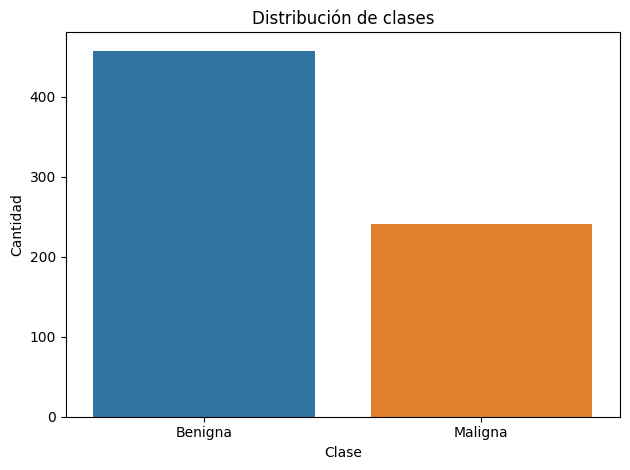

In [ ]:
sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.xticks(
    ticks=[0, 1],
    labels=["Benigna", "Maligna"]
)

plt.tight_layout()
plt.show()

In [46]:
df['Class'].value_counts()

Class
2    458
4    241
Name: count, dtype: int64

In [47]:
df['Class'].value_counts(normalize=True) * 100

Class
2    65.522175
4    34.477825
Name: proportion, dtype: float64

### Distribución de características entre Benigno y Maligno

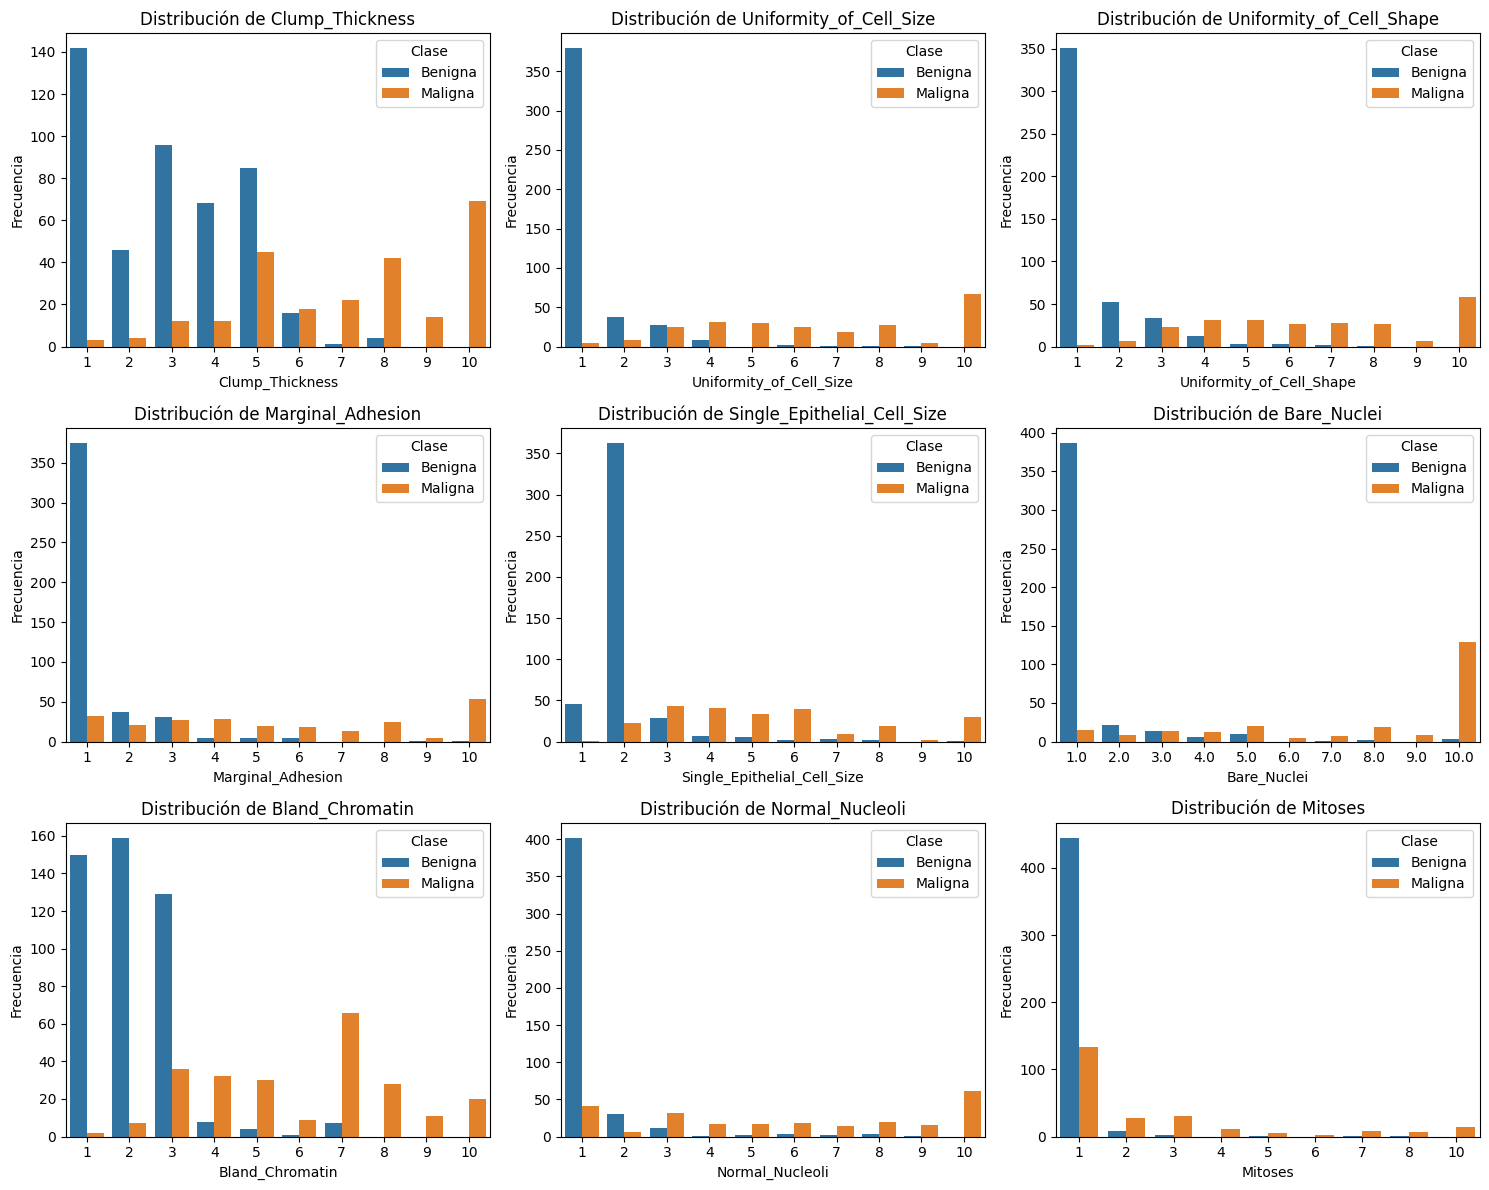

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

numeric_cols = df.select_dtypes(include="number").columns

numeric_cols = [
    col for col in numeric_cols
    if col not in ['Class', 'Sample_Id']
]

ncols = 3
nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=ax,
        hue='Class'
    )
    ax.legend(title="Clase", labels=["Benigna", "Maligna"])
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

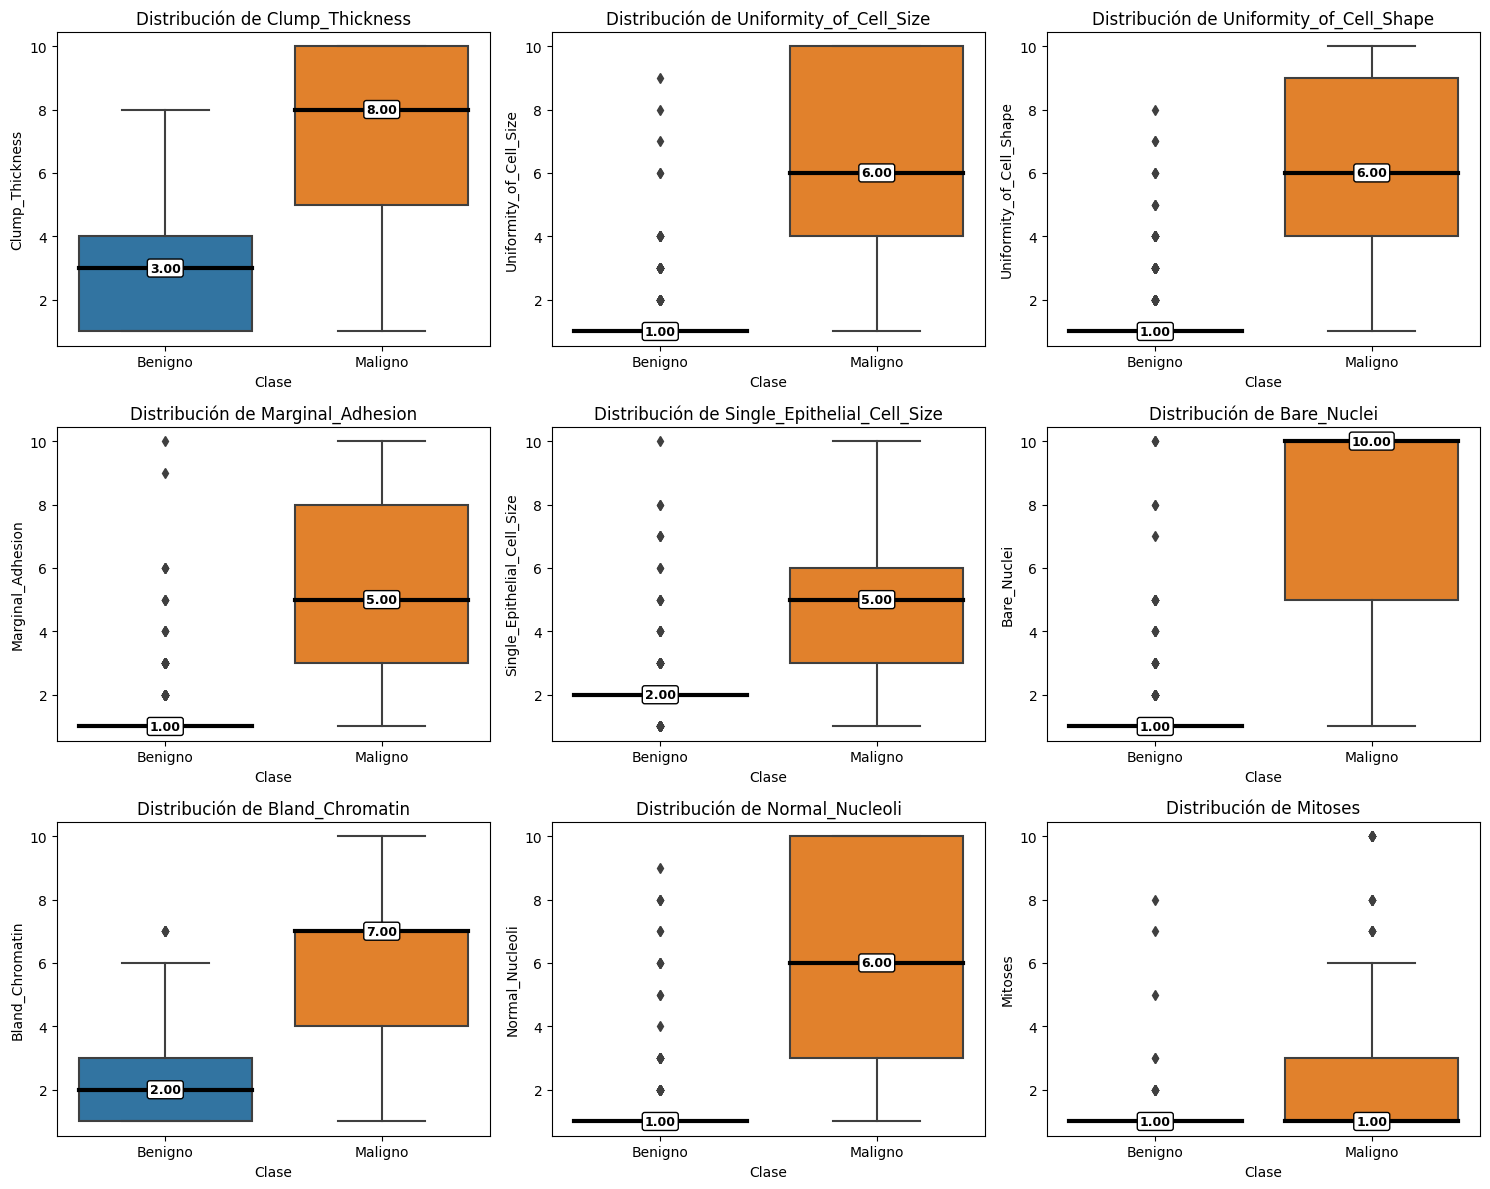

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

numeric_cols = df.select_dtypes(include="number").columns

numeric_cols = [
    col for col in numeric_cols
    if col not in ["Class", "Sample_Id"]
]

ncols = 3
nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):

    sns.boxplot(
        data=df,
        x="Class",
        y=col,
        ax=ax,
        medianprops={"color": "black", "linewidth": 3}
    )

    # Medianas de cada clase
    medians = df.groupby("Class")[col].median()

    for i, (clase, median) in enumerate(medians.items()):
        ax.text(
            i,
            median,
            f"{median:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="black"
            )
        )
    
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("Clase")
    ax.set_ylabel(col)
    ax.set_xticklabels(["Benigno", "Maligno"])

# Eliminar ejes sobrantes
for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

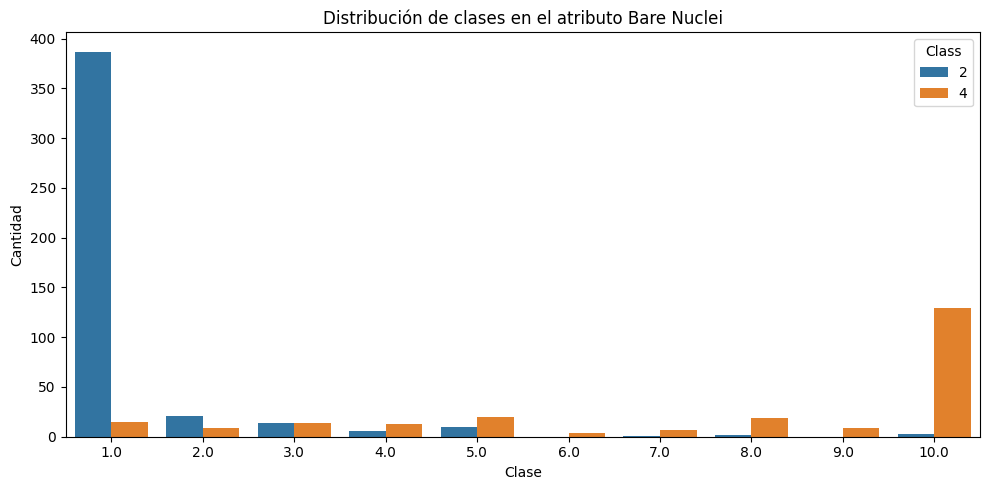

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Bare_Nuclei",
    hue='Class'
)

plt.title("Distribución de clases en el atributo Bare Nuclei")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()

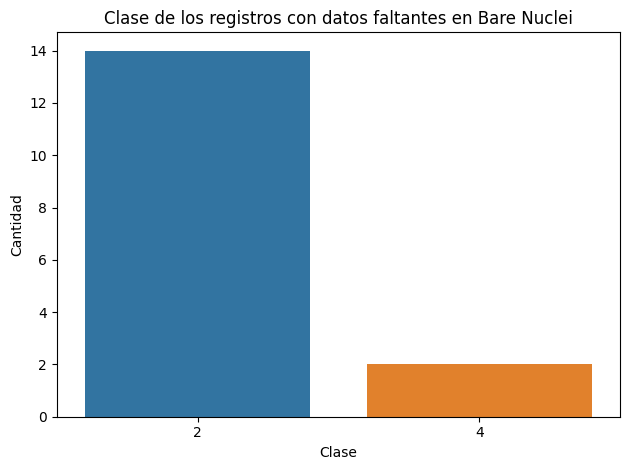

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Registros donde Bare Nuclei está vacío
df_missing = df[df["Bare_Nuclei"].isna()]

# Graficar la clase de esos registros
sns.countplot(
    data=df_missing,
    x="Class"
)

plt.title("Clase de los registros con datos faltantes en Bare Nuclei")
plt.xlabel("Clase")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()

In [52]:
df.isna().sum()

Sample_Id                       0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64

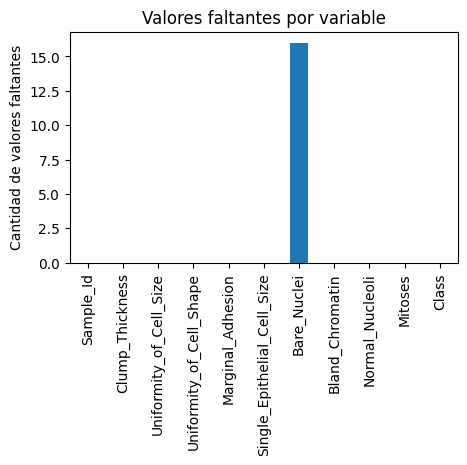

In [53]:
plt.figure(figsize=(5, 3))
df.isna().sum().plot(kind='bar')
plt.ylabel('Cantidad de valores faltantes')
plt.title('Valores faltantes por variable')
plt.show()

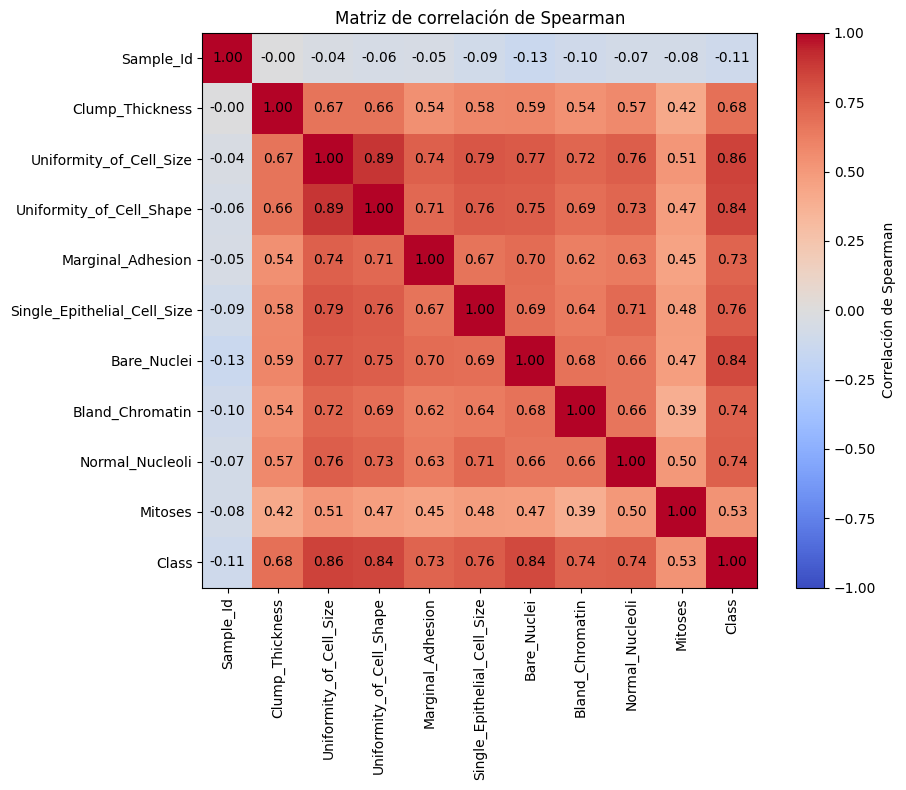

In [54]:
import matplotlib.pyplot as plt

# Seleccionar variables numéricas
numeric_cols = df.select_dtypes(include="number").columns

# Matriz de correlación de Pearson
corr = df[numeric_cols].corr(method="spearman")

# Graficar
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlación de Spearman")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Mostrar valores
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

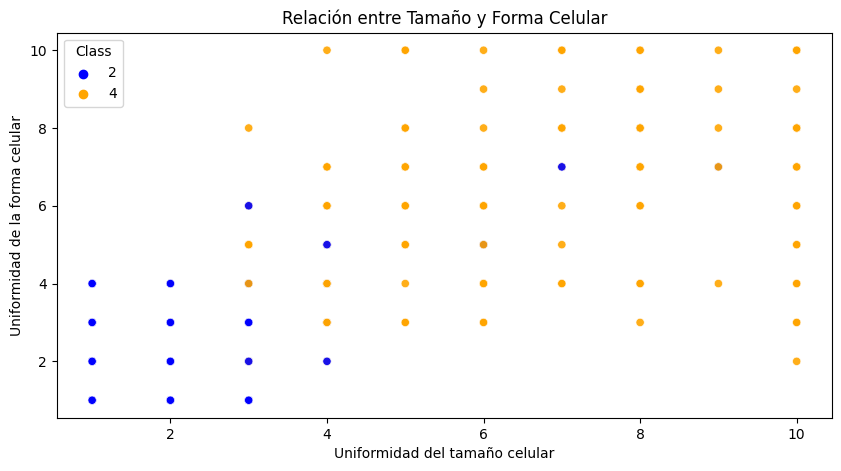

In [55]:
# Grafico de dispersion de las dos variables mas correlacionadas
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x='Uniformity_of_Cell_Size',
    y='Uniformity_of_Cell_Shape',
    hue='Class',
    palette=['blue', 'orange'],
    alpha=0.9
)
plt.title('Relación entre Tamaño y Forma Celular')
plt.xlabel('Uniformidad del tamaño celular')
plt.ylabel('Uniformidad de la forma celular')
plt.show()

# Limpieza de datos

Eliminamos los 8 valores duplicados

In [56]:
clean_data = df.copy()
clean_data = clean_data.drop_duplicates()
clean_data

,Sample_Id,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,2
695,841769,2,1,1,1,2,1.0,1,1,1,2
696,888820,5,10,10,3,7,3.0,8,10,2,4
697,897471,4,8,6,4,3,4.0,10,6,1,4


In [57]:
# Copia de los datos originales
clean_data = df.copy()

# Convertir Bare_Nuclei a numérico
clean_data["Bare_Nuclei"] = pd.to_numeric(
    clean_data["Bare_Nuclei"],
    errors="coerce"
)

# Guardar valores antes de limpiar
bare_antes = clean_data["Bare_Nuclei"].copy()
nulos_antes = bare_antes.isna().sum()

# Mediana de benignos y malignos
mediana_b = clean_data.loc[
    clean_data["Class"] == 2, "Bare_Nuclei"
].median()

mediana_m = clean_data.loc[
    clean_data["Class"] == 4, "Bare_Nuclei"
].median()

print("Mediana en benignos:", mediana_b)
print("Mediana en malignos:", mediana_m)

# Rellenar valores faltantes según el diagnóstico
clean_data.loc[
    (clean_data["Class"] == 2) &
    (clean_data["Bare_Nuclei"].isna()),
    "Bare_Nuclei"
] = mediana_b

clean_data.loc[
    (clean_data["Class"] == 4) &
    (clean_data["Bare_Nuclei"].isna()),
    "Bare_Nuclei"
] = mediana_m

# Convertir a entero
clean_data["Bare_Nuclei"] = clean_data["Bare_Nuclei"].astype(int)

# Contar nulos después
nulos_despues = clean_data["Bare_Nuclei"].isna().sum()

print("Nulos ANTES:", nulos_antes)
print("Nulos DESPUÉS:", nulos_despues)

Mediana en benignos: 1.0
Mediana en malignos: 10.0
Nulos ANTES: 16
Nulos DESPUÉS: 0


In [58]:
clean_data.isna().sum()

Sample_Id                      0
Clump_Thickness                0
Uniformity_of_Cell_Size        0
Uniformity_of_Cell_Shape       0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

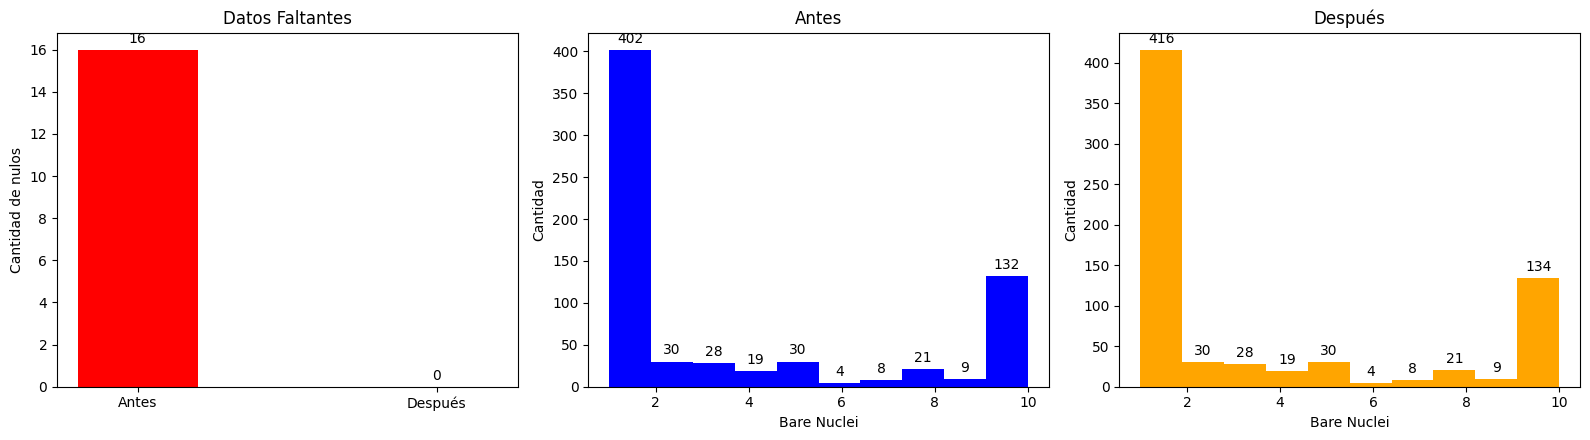

In [59]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

# Nulos
bars = axs[0].bar(
    ["Antes", "Después"],
    [nulos_antes, nulos_despues],
    color=["red", "blue"],
    width=0.4
)

axs[0].bar_label(bars, padding=3)
axs[0].set_title("Datos Faltantes")
axs[0].set_ylabel("Cantidad de nulos")


# Antes
conteos, bins, patches = axs[1].hist(
    bare_antes.dropna(),
    bins=10,
    color="blue"
)

axs[1].bar_label(
    patches,
    labels=[str(int(x)) for x in conteos],
    padding=3
)

axs[1].set_title("Antes")
axs[1].set_xlabel("Bare Nuclei")
axs[1].set_ylabel("Cantidad")


# Después
conteos, bins, patches = axs[2].hist(
    clean_data["Bare_Nuclei"],
    bins=10,
    color="orange"
)

axs[2].bar_label(
    patches,
    labels=[str(int(x)) for x in conteos],
    padding=3
)

axs[2].set_title("Después")
axs[2].set_xlabel("Bare Nuclei")
axs[2].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()

In [60]:
registros_imputados = clean_data.loc[
    bare_antes.isna(),
    ["Class", "Bare_Nuclei"]
]

display(registros_imputados)

,Class,Bare_Nuclei
23,4,10
40,2,1
139,2,1
145,2,1
158,2,1
164,2,1
235,2,1
249,2,1
275,2,1
292,4,10


In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables para PCA
features = [
    col for col in clean_data.select_dtypes(include="number").columns
    if col not in ["Sample_Id", "Class"]
]

X = clean_data[features]
y = clean_data["Class"]

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear DataFrame con los componentes
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Class"] = y.values

# Varianza explicada
print("Varianza explicada:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {pca.explained_variance_ratio_.sum():.2%}")

Varianza explicada:
PC1: 65.48%
PC2: 8.65%
Total: 74.13%


In [ ]:


# Variables para PCA
features = [
    col for col in clean_data.select_dtypes(include="number").columns
    if col not in ["Sample_Id", "Class"]
]

# Datos y diagnóstico
X = clean_data[features]
y = clean_data["Class"]

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_escalado = pd.DataFrame(
    X_scaled,
    columns=features
)

df_escalado["Class"] = y.map({
    2: "Benigna",
    4: "Maligna"
})

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

var_todas = pca.explained_variance_ratio_ * 100

var_pc1 = var_todas[0]
var_pc2 = var_todas[1]
var_acum = var_pc1 + var_pc2

df_pca = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

df_pca["Class"] = y.map({
    2: "Benigna",
    4: "Maligna"
})

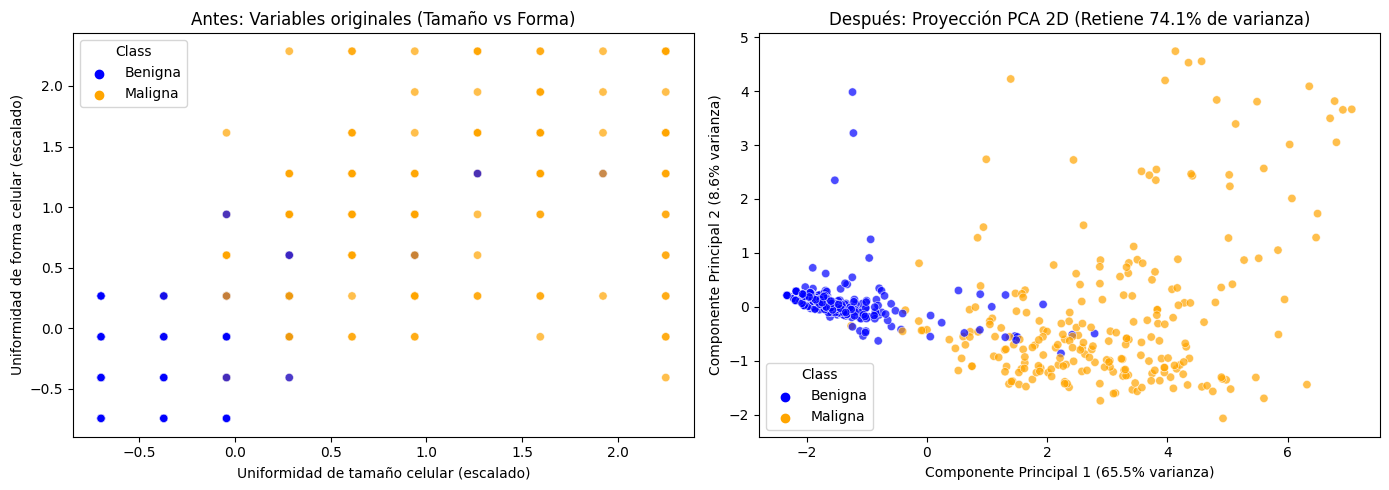

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Antes
sns.scatterplot(
    data=df_escalado,
    x="Uniformity_of_Cell_Size",
    y="Uniformity_of_Cell_Shape",
    hue="Class",
    palette=["blue", "orange"],
    alpha=0.7,
    ax=axes[0]
)

axes[0].set_title("Antes: Variables originales (Tamaño vs Forma)")
axes[0].set_xlabel("Uniformidad de tamaño celular (escalado)")
axes[0].set_ylabel("Uniformidad de forma celular (escalado)")


# Gráfica Después
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Class",
    palette=['blue', 'orange'],
    alpha=0.7,
    ax=axes[1]
)

axes[1].set_title(
    f"Después: Proyección PCA 2D "
    f"(Retiene {var_acum:.1f}% de varianza)"
)

axes[1].set_xlabel(
    f"Componente Principal 1 ({var_pc1:.1f}% varianza)"
)

axes[1].set_ylabel(
    f"Componente Principal 2 ({var_pc2:.1f}% varianza)"
)

plt.tight_layout()
plt.show()

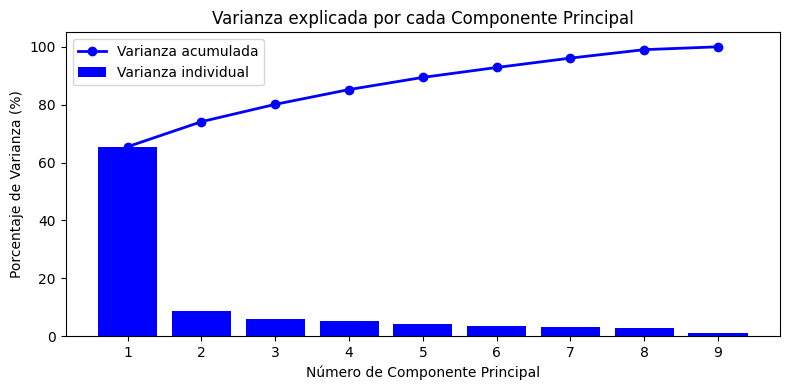

In [66]:
plt.figure(figsize=(8, 4))

componentes = np.arange(1, len(var_todas) + 1)

plt.bar(
    componentes,
    var_todas,
    color="blue",
    label="Varianza individual"
)

plt.plot(
    componentes,
    np.cumsum(var_todas),
    color="blue",
    marker="o",
    linewidth=2,
    label="Varianza acumulada"
)

plt.title("Varianza explicada por cada Componente Principal")
plt.xlabel("Número de Componente Principal")
plt.ylabel("Porcentaje de Varianza (%)")
plt.xticks(componentes)
plt.legend()

plt.tight_layout()
plt.show()